episode length 93 total reward -370.69


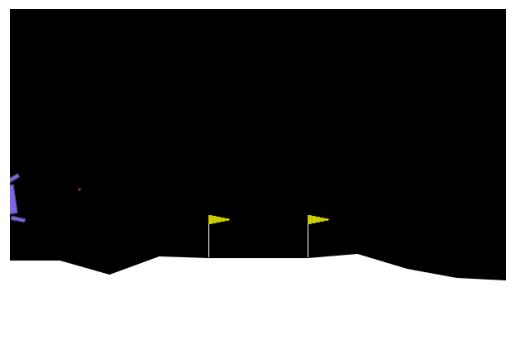

In [12]:
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display, clear_output

class RandomPolicy:
    def __init__(self, action_space):
        self.action_space = action_space
        
    def __call__(self, observation):
        return self.action_space.sample()


class EpisodeRenderer:
    def __init__(self, env, policy):
        self.env = env
        self.policy = policy

    def run_episode(self):
        observation, info = self.env.reset()
        frames = []

        # Run one episode
        done = False
        count = 0
        total_reward = 0
        while not done:
            action = self.policy(observation)  # Replace with your agent's action
            observation, reward, terminated, truncated, info = self.env.step(action)
            frame = self.env.render()  # Get frame as NumPy array
            frames.append(frame)
            count += 1
            total_reward += reward
            done = terminated or truncated

        return dict(
            frames=frames,
            length=count,
            total_reward=total_reward,
        )

    def generate_animation(self, frames):
        fig, ax = plt.subplots()
        ax.axis("off")
        img = ax.imshow(frames[0])
        
        # Animation function
        def update(frame):
            img.set_array(frame)
            return [img]
        
        # Create animation
        ani = animation.FuncAnimation(fig, update, frames=frames, interval=50, blit=True)
        return ani


env = gym.make("LunarLander-v3", render_mode="rgb_array")
policy = RandomPolicy(env.action_space)
renderer = EpisodeRenderer(env, policy)
results = renderer.run_episode()
ani = renderer.generate_animation(results['frames'])
env.close()
print(f"episode length {results['length']} total reward {results['total_reward']:.2f}")
HTML(ani.to_jshtml())